# Crop Recommendation — Data Processing, Data Analytics & Modeling
### Smart Crop Advisory System using Data Analytics

**Purpose of this notebook:**
This notebook covers the core Data Science pipeline for the **crop recommendation
component** of the project — using the standard Kaggle Crop Recommendation Dataset
(2200 rows, 22 crop classes, 7 features: N, P, K, temperature, humidity, ph, rainfall).

Unlike the synthetic timeline-feedback dataset (which was deliberately messy), this
dataset is a well-established, clean benchmark dataset. So the emphasis here shifts
from heavy cleaning to **exploratory data analysis, preprocessing, model comparison,
and explainability** — which is exactly what's expected once a dataset is already in
good shape.

**Notebook sections:**
1. Setup & Data Loading
2. Initial Inspection & Data Quality Checks
3. Exploratory Data Analysis (Data Analytics)
4. Preprocessing (Encoding, Splitting, Scaling)
5. Model Training — Comparing 5 Classification Algorithms
6. Model Evaluation & Comparison
7. Feature Importance
8. Explainability with SHAP
9. Saving the Final Model


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("crop_recommendation.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Initial Inspection & Data Quality Checks
Even though this is a well-known benchmark dataset, we still perform the standard
data-quality checks — this is a required step in any data science pipeline, and the
results are worth stating explicitly in your report (a clean dataset is a *finding*,
not something to skip verifying).

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [3]:
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumber of unique crops:", df['label'].nunique())
print("\nClass distribution (rows per crop):")
print(df['label'].value_counts())


Missing values per column:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0

Number of unique crops: 22

Class distribution (rows per crop):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


**Observation:** No missing values, no duplicate rows, and the dataset is perfectly
balanced (100 rows per crop class). This confirms minimal cleaning is required here —
in contrast to the synthetic feedback dataset used elsewhere in this project, which
needed extensive cleaning. We proceed directly to analysis.

## 3. Exploratory Data Analysis (Data Analytics)
This section analyzes feature distributions and relationships to understand what drives
crop suitability — the analytical work that justifies our modeling choices later.

### 3.1 Feature Distributions
Histograms of each numeric feature show their overall spread across all crops.

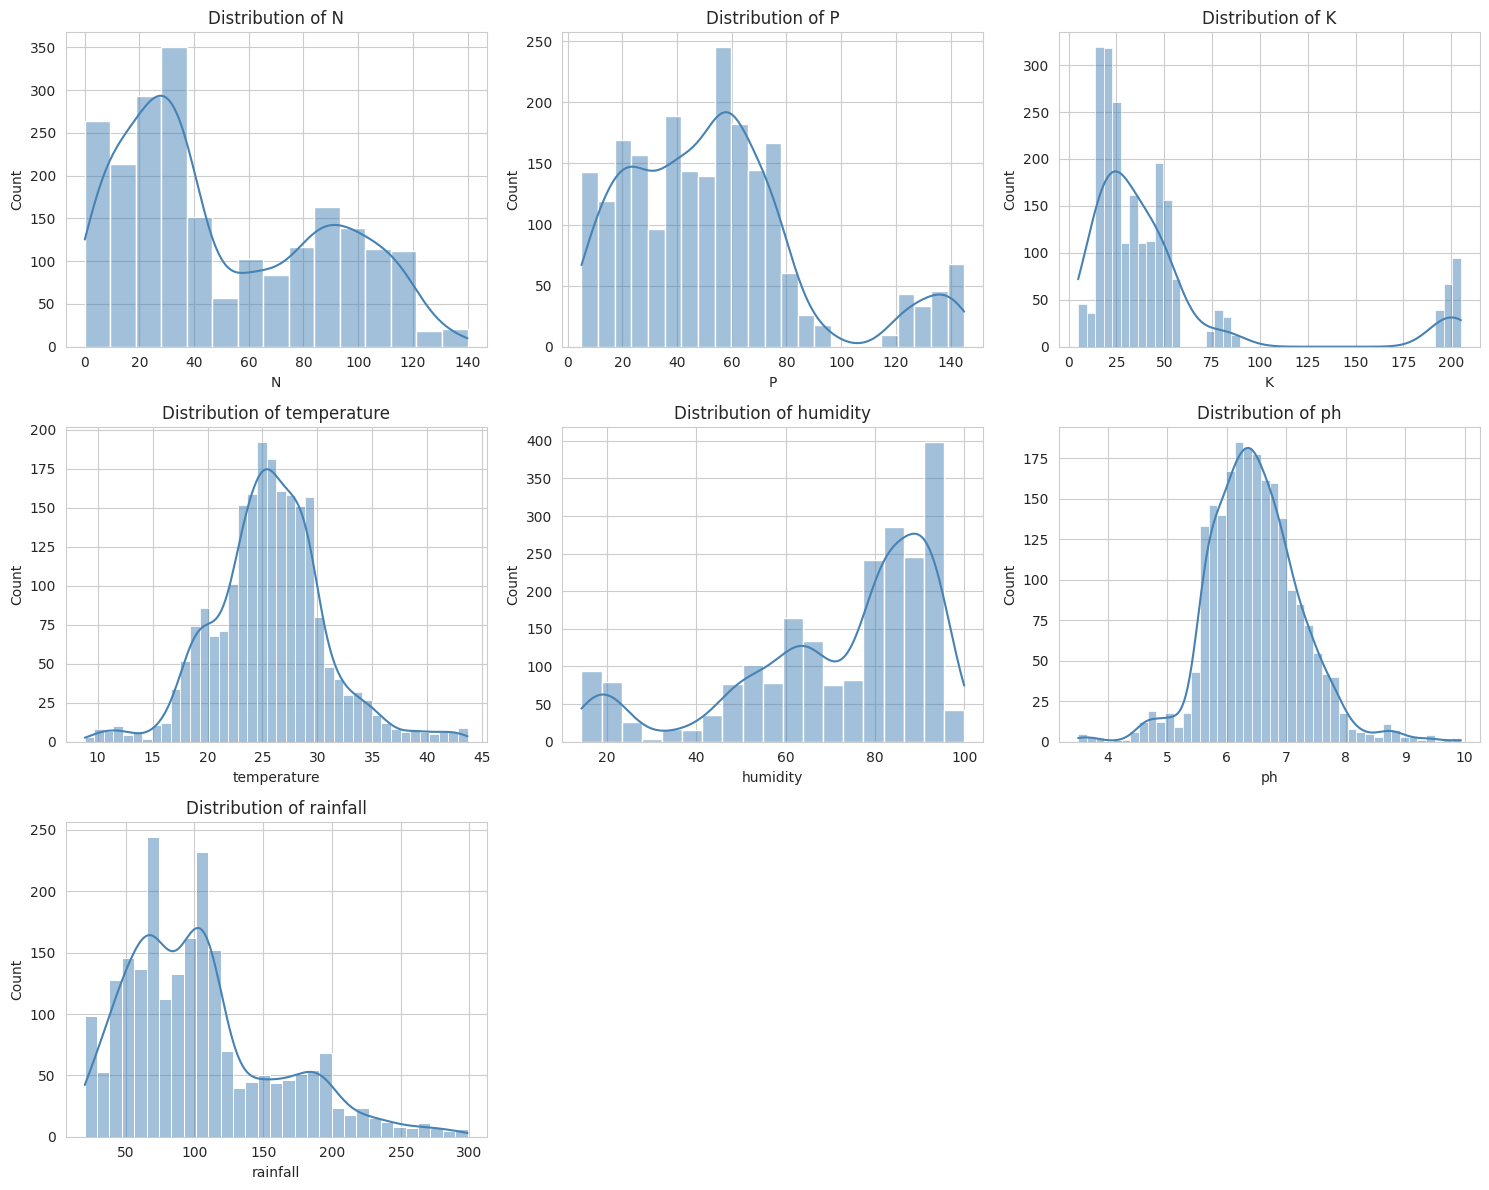

In [5]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 3.2 Correlation Heatmap
Shows relationships between numeric features — useful to check for multicollinearity and to understand which features move together.

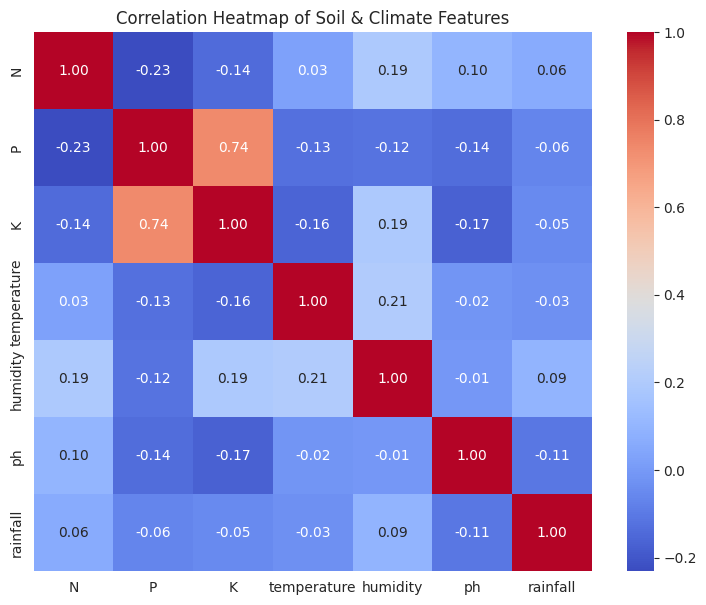

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Soil & Climate Features")
plt.show()


### 3.3 Feature Values by Crop (Boxplots)
Shows how each feature varies across a selected set of crops — reveals which features are strong discriminators (e.g. rice needs high rainfall, chickpea needs low rainfall).

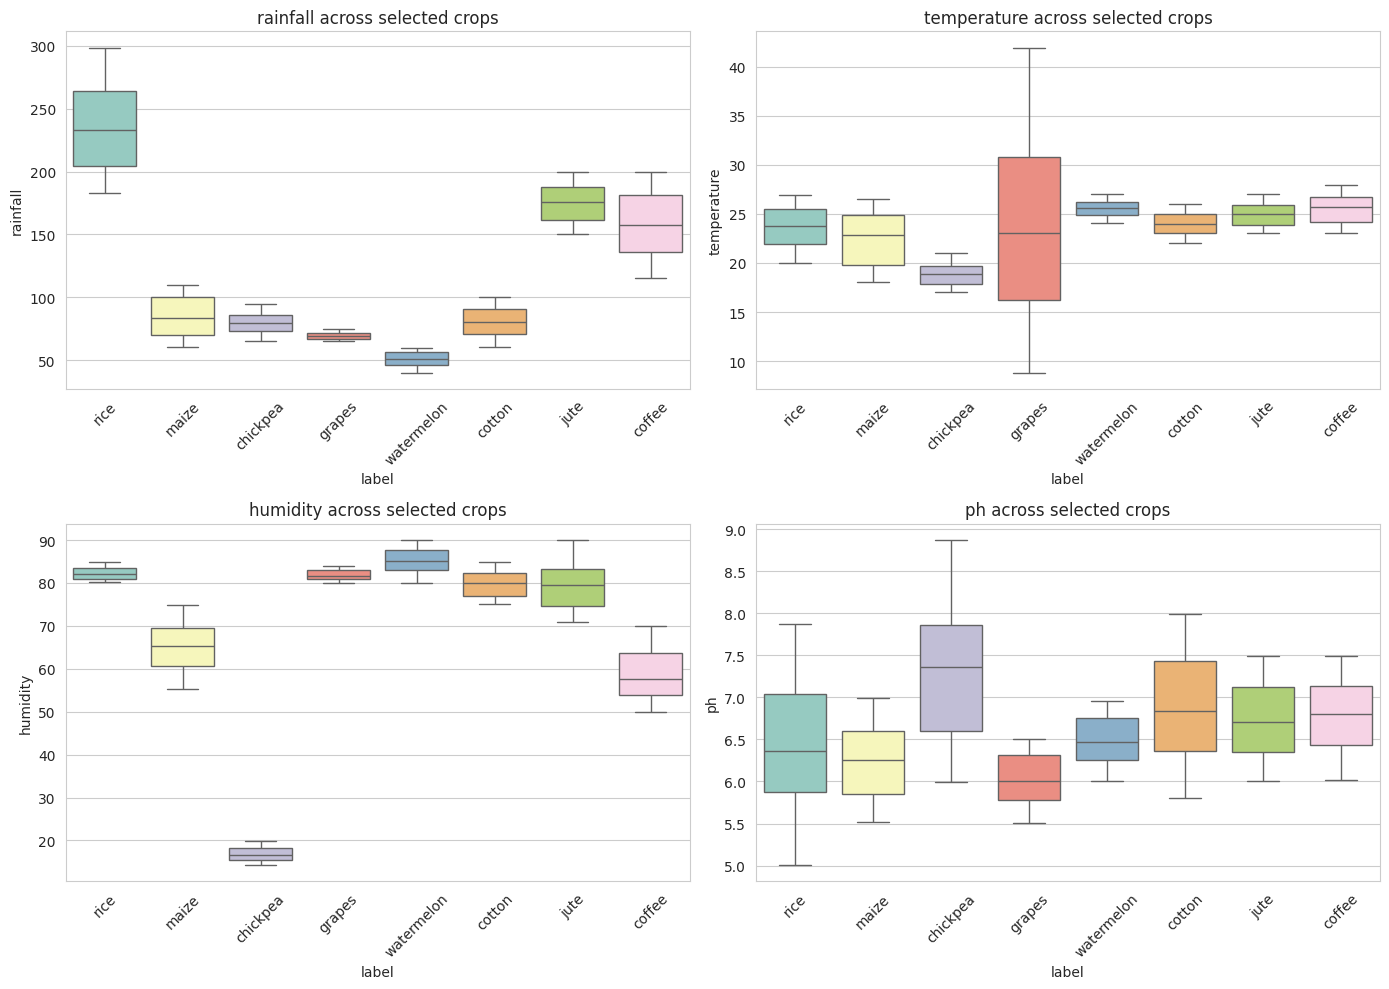

In [7]:
sample_crops = ["rice", "maize", "chickpea", "coffee", "cotton", "watermelon", "grapes", "jute"]
df_sample = df[df["label"].isin(sample_crops)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ["rainfall", "temperature", "humidity", "ph"]):
    sns.boxplot(data=df_sample, x="label", y=col, ax=ax, palette="Set3")
    ax.set_title(f"{col} across selected crops")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.4 Average NPK Requirement per Crop
A grouped bar chart summarizing average nutrient requirement — directly useful content for explaining crop-soil matching to a non-technical audience (like your teacher/evaluators).

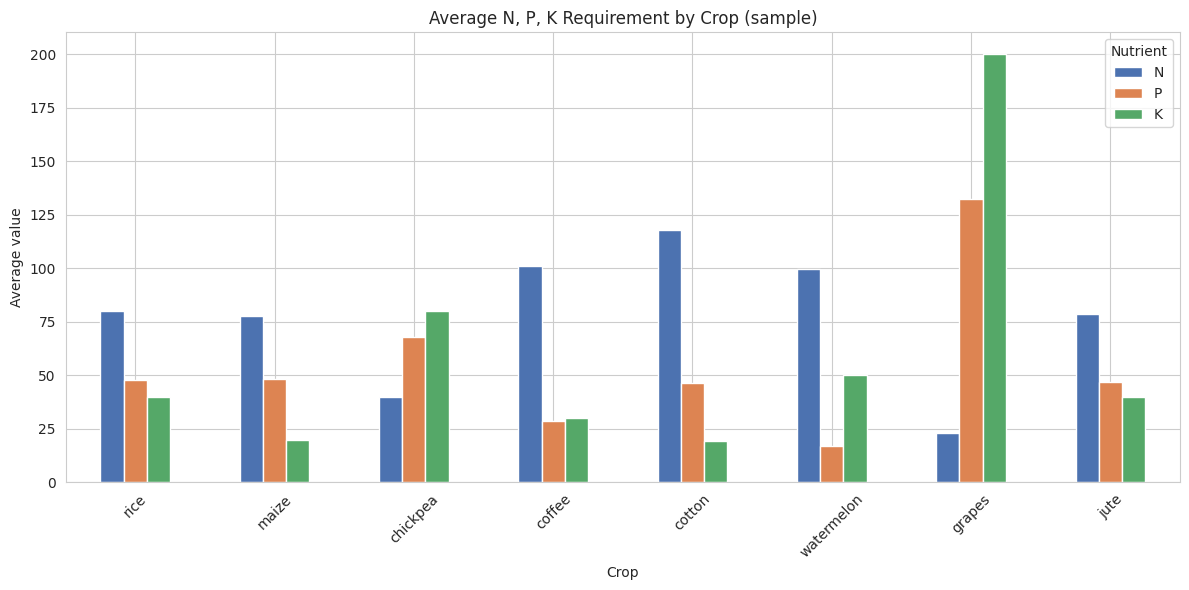

In [8]:
npk_avg = df.groupby("label")[["N", "P", "K"]].mean().loc[sample_crops]

npk_avg.plot(kind="bar", figsize=(12, 6), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Average N, P, K Requirement by Crop (sample)")
plt.ylabel("Average value")
plt.xlabel("Crop")
plt.xticks(rotation=45)
plt.legend(title="Nutrient")
plt.tight_layout()
plt.show()


### 3.5 Pairplot of Key Features
Visualizes pairwise relationships and shows how well-separated crop clusters are in feature space — a strong visual for demonstrating the dataset is genuinely learnable.

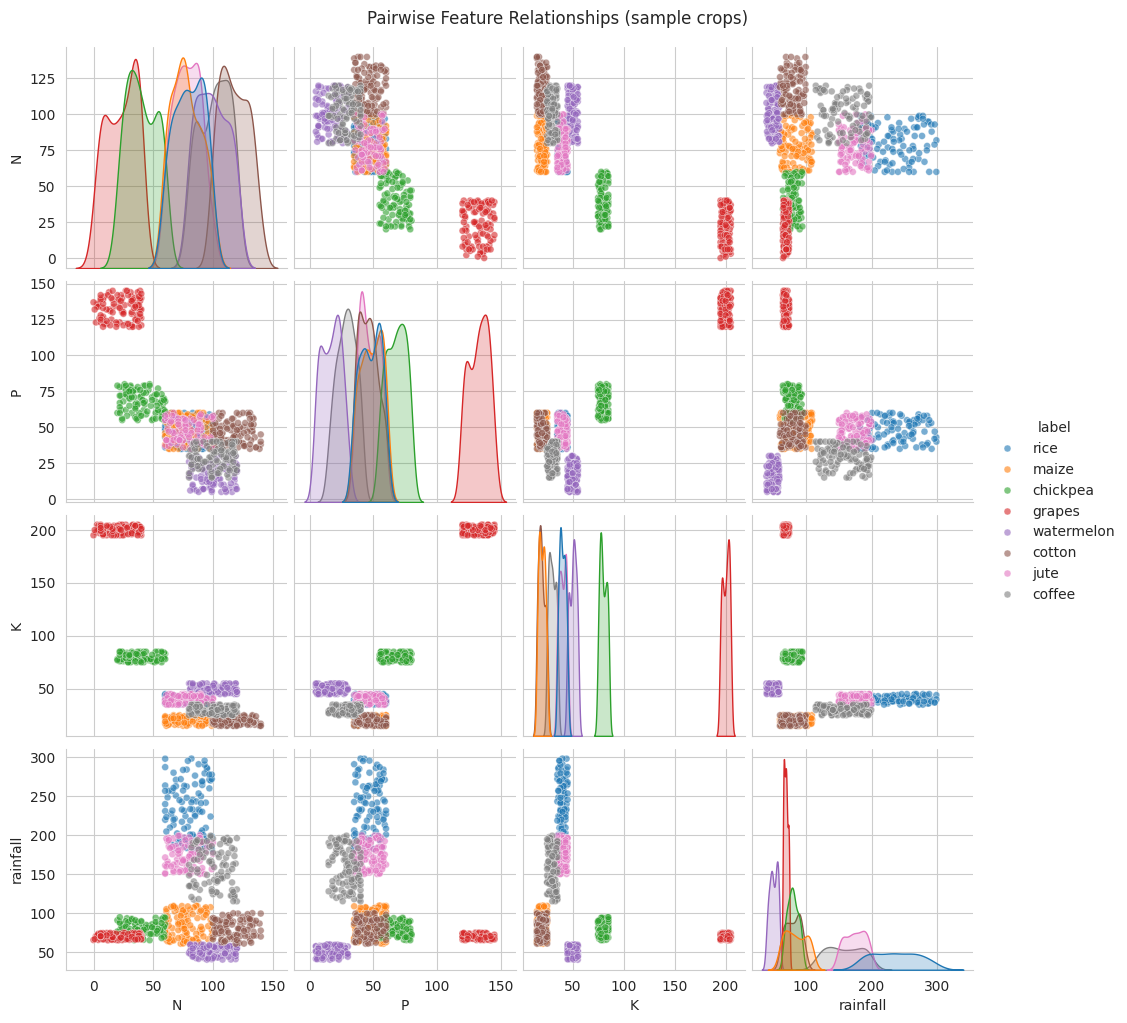

In [9]:
sns.pairplot(df_sample, vars=["N", "P", "K", "rainfall"], hue="label", palette="tab10",
             plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Pairwise Feature Relationships (sample crops)", y=1.02)
plt.show()


## 4. Preprocessing
Even a clean dataset needs standard preprocessing before modeling:
- **Label Encoding** the target (`label`) column, since it's text
- **Train-Test Split** (80-20, stratified to preserve class balance)
- **Feature Scaling** (StandardScaler) — needed here because unlike the tree-only
  approach in the timeline module, we are also training SVM and KNN, which are
  distance-based and scale-sensitive.

In [10]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

X = df[features]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1760, 7)  Test shape: (440, 7)


## 5. Model Training — Comparing 5 Classification Algorithms
We train and compare five commonly used classifiers on this problem. Tree-based models
(Random Forest, Decision Tree) use the unscaled features (scaling doesn't affect them);
distance-based models (SVM, KNN) and Naive Bayes use the scaled features.

In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

# Tree-based models: use unscaled data (interpretable, scale-invariant)
tree_models = ["Random Forest", "Decision Tree"]

results = {}
trained_models = {}

for name, model in models.items():
    if name in tree_models:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    trained_models[name] = model
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="weighted"),
        "Recall": recall_score(y_test, preds, average="weighted"),
        "F1-score": f1_score(y_test, preds, average="weighted"),
    }

results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
results_df


,Accuracy,Precision,Recall,F1-score
Random Forest,0.995455,0.995671,0.995455,0.995452
Naive Bayes,0.995455,0.995868,0.995455,0.995443
SVM,0.984091,0.985610,0.984091,0.984038
Decision Tree,0.979545,0.980598,0.979545,0.979423
KNN,0.979545,0.980356,0.979545,0.979283


## 6. Model Evaluation & Comparison
A bar chart comparison makes it easy to visually justify the choice of Random Forest as
the final model, and a confusion matrix for the best model shows exactly where
misclassifications (if any) occur.

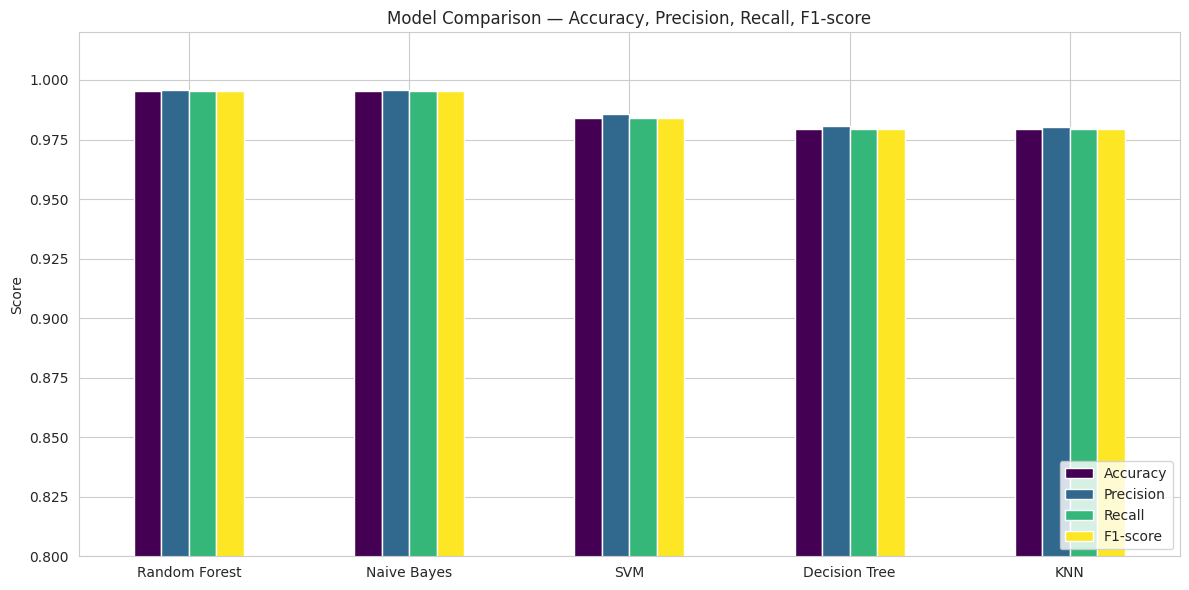

In [12]:
results_df.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Model Comparison — Accuracy, Precision, Recall, F1-score")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [13]:
best_model_name = results_df["Accuracy"].idxmax()
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")

if best_model_name in tree_models:
    preds_best = best_model.predict(X_test)
else:
    preds_best = best_model.predict(X_test_scaled)

print("\nClassification Report:\n")
print(classification_report(y_test, preds_best, target_names=le.classes_))


Best performing model: Random Forest

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       

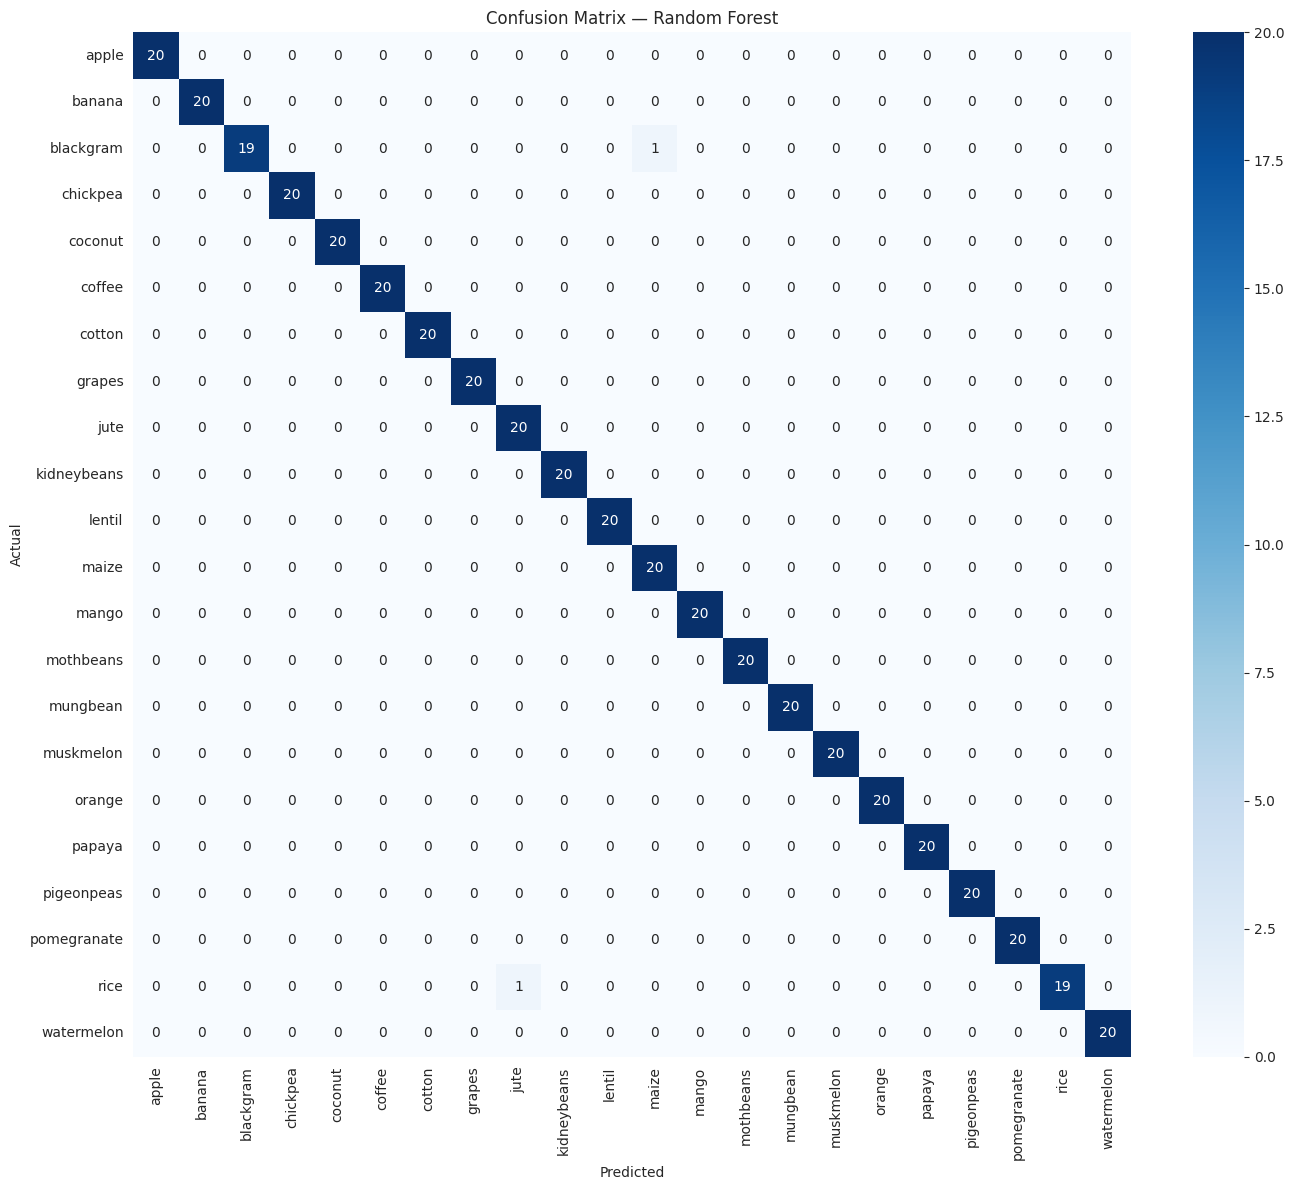

In [14]:
cm = confusion_matrix(y_test, preds_best)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Feature Importance
For the Random Forest model, we can directly extract which features contributed most
to its decisions on average — a simpler, faster complement to SHAP (covered next).

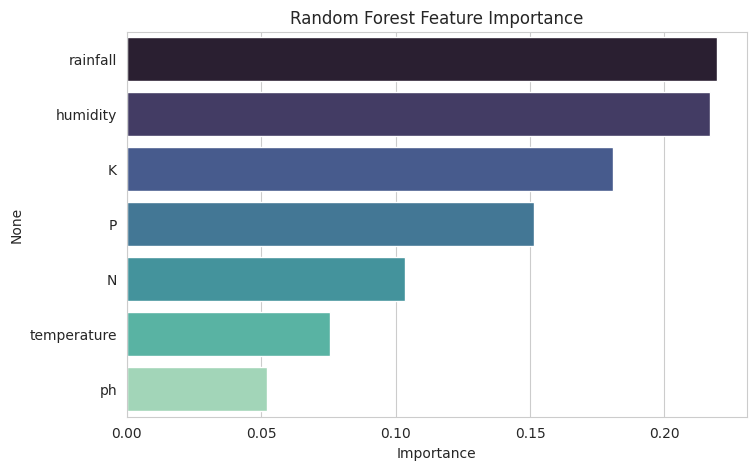

In [15]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()


**Note on interpretation:** Feature importance shows what mattered *on average*
across all predictions. It cannot explain a single, specific prediction — that's exactly
the gap SHAP fills in the next section.

## 8. Explainability with SHAP
SHAP (SHapley Additive exPlanations) explains individual predictions by attributing
credit to each input feature, based on Shapley values from cooperative game theory.
Here we use `TreeExplainer`, which is optimized for tree-based models like Random
Forest.

In [16]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# shap_values is a list of arrays (one per class) for multi-class RF
print("Number of classes explained:", len(shap_values) if isinstance(shap_values, list) else shap_values.shape)


Number of classes explained: (440, 7, 22)


### 8.1 Global Explanation — SHAP Summary Plot
Shows which features matter most overall for crop prediction, across the whole test set (for one representative class, 'rice', as an example).

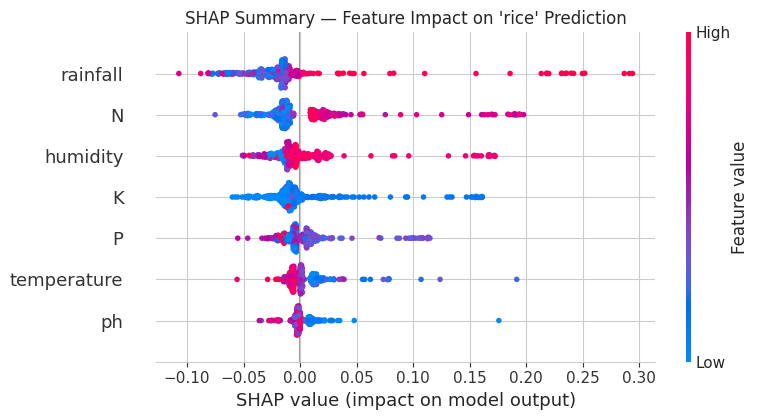

In [17]:
rice_idx = list(le.classes_).index("rice")

plt.figure()
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[rice_idx], X_test, feature_names=features, show=False)
else:
    shap.summary_plot(shap_values[:, :, rice_idx], X_test, feature_names=features, show=False)
plt.title("SHAP Summary — Feature Impact on 'rice' Prediction")
plt.tight_layout()
plt.show()


### 8.2 Local Explanation — Single Prediction
Shows exactly why the model predicted a specific crop for one individual sample —
this is the version that answers "why did the model recommend this for *this* farmer's
soil data?".

In [18]:
sample_idx = 0
sample_input = X_test.iloc[[sample_idx]]
sample_pred = best_model.predict(sample_input if best_model_name in tree_models else scaler.transform(sample_input))
predicted_crop = le.inverse_transform(sample_pred)[0]

print("Sample soil/climate input:")
print(sample_input)
print(f"\nPredicted crop: {predicted_crop}")

pred_class_idx = sample_pred[0]
if isinstance(shap_values, list):
    sample_shap_values = shap_values[pred_class_idx][sample_idx]
    base_value = explainer.expected_value[pred_class_idx]
else:
    sample_shap_values = shap_values[sample_idx, :, pred_class_idx]
    base_value = explainer.expected_value[pred_class_idx]

shap_explanation = pd.Series(sample_shap_values, index=features).sort_values(key=abs, ascending=False)
print("\nFeature contribution to this specific prediction:")
print(shap_explanation)


Sample soil/climate input:
       N   P  K  temperature  humidity        ph   rainfall
1609  13  23  6    23.961476  90.26408  7.365338  102.69587

Predicted crop: orange

Feature contribution to this specific prediction:
K              0.356359
humidity       0.170303
P              0.157714
rainfall       0.105624
N              0.103880
ph             0.031584
temperature    0.004051
dtype: float64


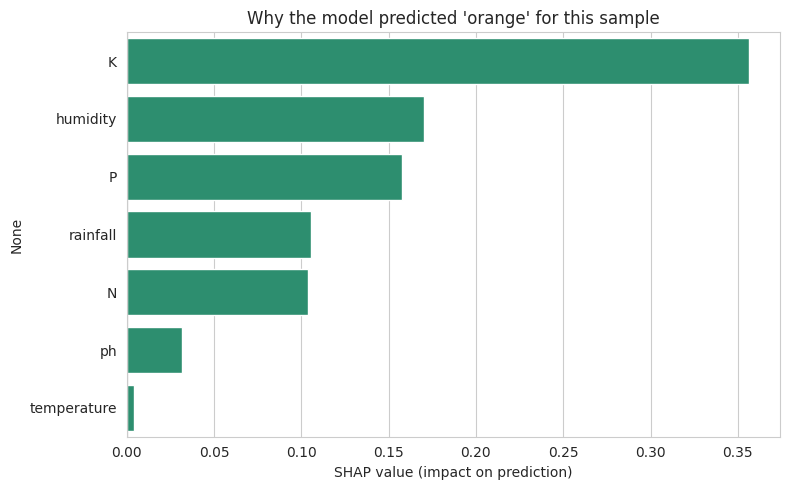

In [19]:
plt.figure(figsize=(8, 5))
colors = ["#D85A30" if v < 0 else "#1D9E75" for v in shap_explanation.values]
sns.barplot(x=shap_explanation.values, y=shap_explanation.index, palette=colors)
plt.title(f"Why the model predicted '{predicted_crop}' for this sample")
plt.xlabel("SHAP value (impact on prediction)")
plt.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()


## 9. Saving the Final Model
We persist the best-performing model, the label encoder, and the scaler so they can be
reused in the web application without retraining.

In [20]:
import joblib

joblib.dump(rf_model, "crop_recommendation_model.pkl")
joblib.dump(le, "crop_label_encoder.pkl")
joblib.dump(scaler, "crop_feature_scaler.pkl")

print("Model, encoder, and scaler saved.")


Model, encoder, and scaler saved.


## Summary
This notebook covered the complete data science pipeline for the crop recommendation
module: verifying data quality, exploring feature relationships through visual
analytics, preprocessing, training and comparing five classification algorithms,
evaluating the best model, and explaining its predictions using SHAP at both the global
and individual-prediction level. The saved model artifacts are ready to be integrated
into the web application's backend.